### Basic Tutorial: Jax Version


The `LANfactory` package is a light-weight convenience package for training `likelihood approximation networks` (LANs) in PyTorch (or JAX/Flax), 
starting from supplied training data.

[LANs](https://elifesciences.org/articles/65074), although more general in potential scope of applications, were conceived in the context of sequential sampling modeling
to account for cognitive processes giving rise to *choice* and *reaction time* data in *n-alternative forced choice experiments* commonly encountered in the cognitive sciences.

In this quick tutorial we will use the [`ssms`](https://github.com/AlexanderFengler/ssm_simulators) package to generate our training data using such a sequential sampling model (SSM). The use of of the `LANfactory` package is in no way bound to utilize this `ssms` package.

#### Install

To install the `ssms` package type,

`pip install git+https://github.com/AlexanderFengler/ssm_simulators`

To install the `LANfactory` package type,

`pip install git+https://github.com/AlexanderFengler/LANfactory`

Necessary dependency should be installed automatically in the process.

In [1]:
import ssms
import lanfactory
import os
import numpy as np
from copy import deepcopy
import torch
import pickle
from pathlib import Path

In [2]:
# MAKE CONFIGS
RUN_SIMS = True
DEVICE = "cpu"

# Define a model
MODEL = "ddm"
OUT_FOLDER = Path("jax_nb_data") / "training_data"
MODEL_FOLDER = Path("jax_nb_data") / "jax_models" / "lan"
N_DATA_FILES = 2
BATCH_SIZE = 1000
os.makedirs(OUT_FOLDER, exist_ok=True)

# Initialize the generator config (nested config object from ssm-simulators)
generator_config = ssms.config.get_default_generator_config("lan")
generator_config["model"] = MODEL
generator_config["pipeline"]["n_parameter_sets"] = 100
generator_config["pipeline"]["n_cpus"] = 1
generator_config["simulator"]["n_samples"] = 200
generator_config["training"]["n_samples_per_param"] = 200
generator_config["output"]["folder"] = str(OUT_FOLDER)

# Make model config dict
model_config = deepcopy(ssms.config.model_config[MODEL])

In [3]:
# MAKE DATA
if RUN_SIMS:
    for i in range(N_DATA_FILES):
        print(f"Generating data file {i + 1} / {N_DATA_FILES}")
        my_dataset_generator = ssms.dataset_generators.lan_mlp.TrainingDataGenerator(
            config=generator_config, model_config=model_config
        )
        _ = my_dataset_generator.generate_data_training(save=True)

Generating data file 1 / 2


Generating data file 2 / 2


In [4]:
from copy import deepcopy

# MAKE FIXTURE WITH SOMEWHAT RANDOM PROPERTIES
network_config = deepcopy(lanfactory.config.network_configs.network_config_mlp)
network_config["layer_sizes"] = [100, 100, 100, 1]
network_config["activations"] = ["tanh", "tanh", "tanh", "linear"]

print("Network config: ")
print(network_config)

train_config = deepcopy(lanfactory.config.network_configs.train_config_mlp)
train_config["learning_rate"] = 0.000002

# CHECK CORNER CASES
train_config["cpu_batch_size"] = 4096
train_config["gpu_batch_size"] = 4096
train_config["n_epochs"] = 2


print("Train config: ")
print(train_config)

Network config: 
{'layer_sizes': [100, 100, 100, 1], 'activations': ['tanh', 'tanh', 'tanh', 'linear'], 'train_output_type': 'logprob'}
Train config: 
{'cpu_batch_size': 4096, 'gpu_batch_size': 4096, 'n_epochs': 2, 'optimizer': 'adam', 'learning_rate': 2e-06, 'lr_scheduler': 'reduce_on_plateau', 'lr_scheduler_params': {}, 'weight_decay': 0.0, 'loss': 'huber', 'save_history': True}


#### Prepare for Training

Next we set up dataloaders for training. The `LANfactory` provides convenient helper functions for this.

The `make_train_valid_dataloaders` function handles:
- Splitting your data files into training and validation sets
- Creating the appropriate `DatasetTorch` objects
- Wrapping them in PyTorch `DataLoader` objects with sensible defaults

The data is returned as numpy arrays, which JAX handles seamlessly.

In [5]:
# MAKE DATALOADERS

# Data files were generated directly into OUT_FOLDER above
file_list_ = list(Path(OUT_FOLDER).glob("*.pickle"))

# num_workers=0 keeps data loading in-process: ssm-simulators sets the
# multiprocessing start method to "spawn" at import, which is unsafe for
# DataLoader worker processes inside a notebook.
jax_training_dataloader, jax_validation_dataloader, input_dim = lanfactory.trainers.make_train_valid_dataloaders(
    file_ids=file_list_,
    batch_size=BATCH_SIZE,
    network_type="lan",
    train_val_split=0.5,
    num_workers=0,
    pin_memory=False,
)

print(f"Training batches: {len(jax_training_dataloader)}")
print(f"Validation batches: {len(jax_validation_dataloader)}")
print(f"Input dimension: {input_dim}")

Training batches: 80
Validation batches: 80
Input dimension: 6


#### Define Network

In [6]:
# LOAD NETWORK
# Test properties of network
jax_net = lanfactory.trainers.JaxMLPFactory(network_config=network_config, train=True)

# Save model config
# model_folder = os.path.join("data", "jax_models", MODEL)
# os.makedirs(model_folder, exist_ok = True)

# pickle.dump(
#     network_config,
#     open(os.path.join(model_folder,
# 					  "jax_network_config.pickle"), "wb")
# 		)

#### Train 

In [7]:
# Test properties of jax trainer
jax_trainer = lanfactory.trainers.ModelTrainerJaxMLP(
    train_config=train_config,
    model=jax_net,
    train_dl=jax_training_dataloader,
    valid_dl=jax_validation_dataloader,
    pin_memory=False,
)

In [8]:
# Test if training loop works
train_state = jax_trainer.train_and_evaluate(
    output_folder=MODEL_FOLDER,
    output_file_id=MODEL,
    run_id="jax",
    mlflow_on=False,
    verbose=1,
    save_outputs=True,
)

Epoch: 0 of 2
Training - Step: 0 of 80 - Loss: 4.7319036
Epoch 0/2 time: 0.14957714080810547s
Validation - Step: 0 of 80 - Loss: 0.5624591


Epoch 0/2 time: 0.052381038665771484s
Epoch: 0 / 2, test_loss: 0.6855981945991516
Epoch: 1 of 2
Training - Step: 0 of 80 - Loss: 0.5325153
Epoch 1/2 time: 0.0390627384185791s
Validation - Step: 0 of 80 - Loss: 0.38235876
Epoch 1/2 time: 0.017911195755004883s
Epoch: 1 / 2, test_loss: 0.4255990982055664
Saving training history to: jax_nb_data/jax_models/lan/jax_lan_ddm__jax_training_history.csv
Saving model parameters to: jax_nb_data/jax_models/lan/jax_lan_ddm__train_state.jax
Saving training config to: jax_nb_data/jax_models/lan/jax_lan_ddm__train_config.pickle
Saving training data details to: jax_nb_data/jax_models/lan/jax_lan_ddm__data_details.pickle


#### Check Trained Network

We can now re-instantiate our network from the trained weights and check that the output are reasonable.

In [9]:
# Loaded Net
# Test passing network config as path and as object

jax_infer = lanfactory.trainers.JaxMLPFactory(
	            network_config=network_config,
                train=False,
            )

In [10]:
# Test passing train state as path and as object
forward_pass, forward_pass_jitted = jax_infer.make_forward_partial(
    seed=42,
    input_dim=model_config["n_params"] + 2,
    state=os.path.join(MODEL_FOLDER,
					   "jax_lan_" + MODEL + "__train_state.jax"),
    add_jitted=True,
)

In [11]:
import jax.numpy as jnp

# Test parameters:
theta = deepcopy(ssms.config.model_config[MODEL]["default_params"])

# Comparison simulator run
sim_out = ssms.basic_simulators.simulator.simulator(
    model=MODEL, theta=theta, n_samples=50000
)

# Make input matrix
input_mat = jnp.zeros((2000, len(theta) + 2))
for i in range(len(theta)):
    input_mat = input_mat.at[:, i].set(jnp.ones(2000) * theta[i])

input_mat = input_mat.at[:, len(theta)].set(
    jnp.array(
        np.concatenate(
            [
                np.linspace(5, 0, 1000).astype(np.float32),
                np.linspace(0, 5, 1000).astype(np.float32),
            ]
        )
    )
)
input_mat = input_mat.at[:, len(theta) + 1].set(
    jnp.array(
        np.concatenate([np.repeat(-1.0, 1000), np.repeat(1.0, 1000)]).astype(np.float32)
    )
)

net_out = forward_pass_jitted(input_mat)

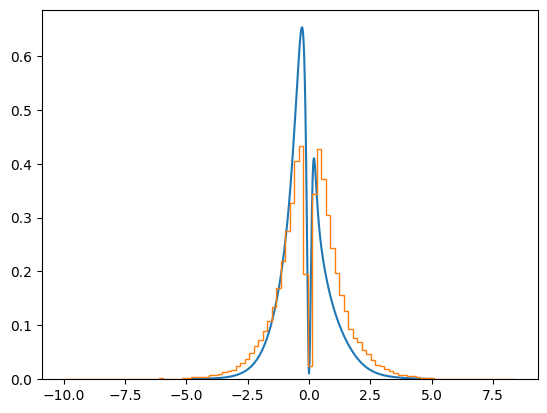

In [12]:
from matplotlib import pyplot as plt

# Plot network log likelihood
plt.plot(np.linspace(-5, 5, 2000).astype(np.float32), np.exp(net_out));

# Plot simulation histogram
plt.hist(
    sim_out["rts"] * sim_out["choices"],
    bins=100,
    histtype="step",
    fill=None,
    density=True,
);